In [70]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import layers, losses
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential

In [71]:
n_curves = 10000
N = 100
t_array = np.linspace(0,2*np.pi,N)
base_array = np.zeros((n_curves,N))

A = np.random.uniform(0.25,1.5,n_curves)
omega = np.random.uniform(0.5,2,n_curves)
phi = np.random.uniform(0, 2*np.pi, n_curves)

for i, n in enumerate(base_array):
    for j in range (N):
        n[j] = A[i]*np.sin(omega[i]*t_array[j]+ phi[i])
base_array.shape

(10000, 100)

In [72]:
dist = np.random.normal
noise_sigma = 0.2 

noise_array = np.zeros((n_curves,N))
for i, n in enumerate(noise_array):
    for j in range (N):
        n[j] = base_array[i][j] + dist(0,noise_sigma,1)[0]

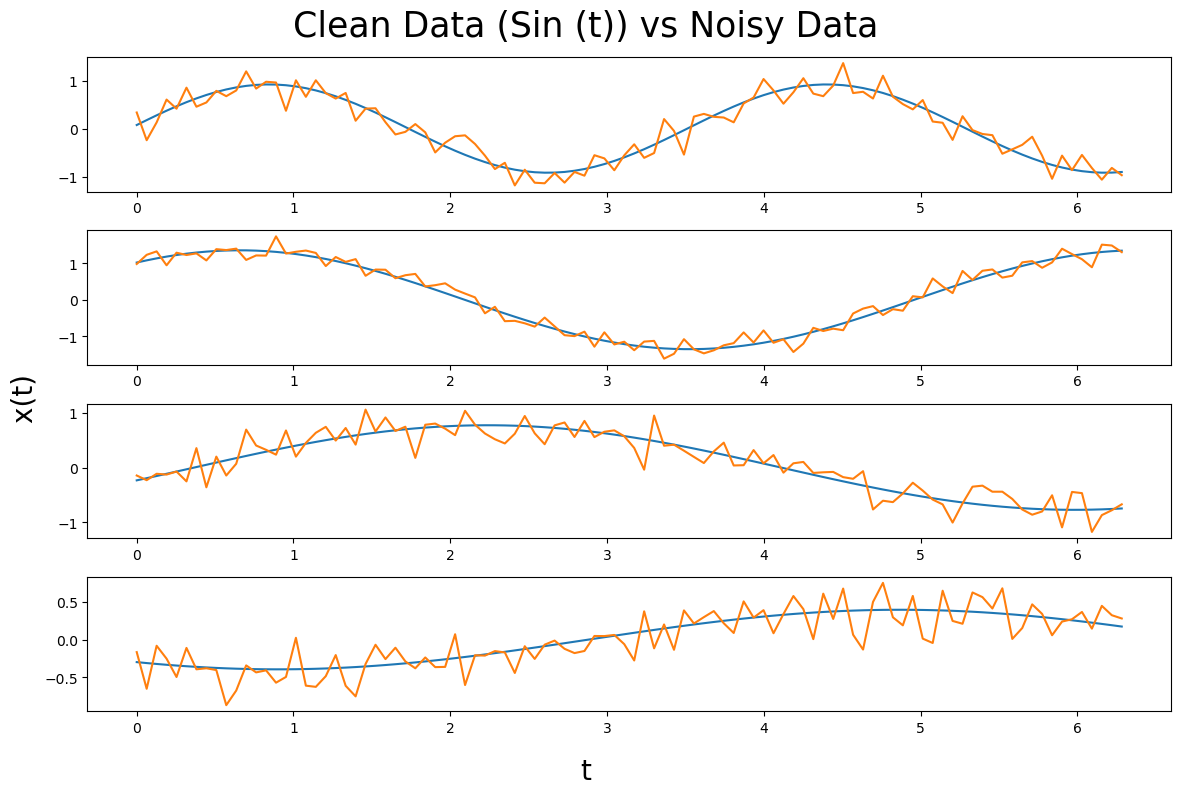

In [73]:
example = [0,1,2,3]
fig, ax = plt.subplots(4,figsize=(12, 8))
for i,n in enumerate(example):
    ax[i].plot(t_array, base_array[n])
    ax[i].plot(t_array,noise_array[n])
fig.suptitle("Clean Data (Sin (t)) vs Noisy Data",fontsize = "25")
fig.supxlabel("t", fontsize = "20")
fig.supylabel("x(t) ", fontsize = "20")

fig.tight_layout()

In [78]:
Ratio = 0.9 

split_i = int(Ratio * n_curves)
base_train,base_valid = np.split(base_array,[split_i],0)
noise_train,noise_valid = np.split(noise_array,[split_i],0)

In [79]:
autoencoder = Sequential([
    Input(shape=(N,)),           #  Input layer
    Dense(64, activation='relu'),  
    Dense(16, activation='relu'),  # latent layer
    Dense(64, activation='relu'),
    Dense(N, activation='linear')  # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,092 (58.95 KB)

 Trainable params: 15,092 (58.95 KB)

 Non-trainable params: 0 (0.00 B)

In [80]:
# Train the model
history = autoencoder.fit(
    noise_train, base_train,         # input = noisy, target = clean
    epochs=50,
    batch_size=128,
    validation_data=(noise_valid,base_valid)
)

# Extract loss values
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2496 - val_loss: 0.0605
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 641us/step - loss: 0.0328 - val_loss: 0.0213
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 628us/step - loss: 0.0152 - val_loss: 0.0125
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 625us/step - loss: 0.0098 - val_loss: 0.0086
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 615us/step - loss: 0.0071 - val_loss: 0.0065
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 609us/step - loss: 0.0056 - val_loss: 0.0055
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 615us/step - loss: 0.0048 - val_loss: 0.0047
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 621us/step - loss: 0.0043 - val_loss: 0.0043
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 620us/step - loss: 0.0039 - val_loss: 0.0040
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 617us/step - loss: 0.0037 - val_loss: 0.0039
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 613us/step - loss: 0.0035 - val_loss: 0.0036
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 608us/step -

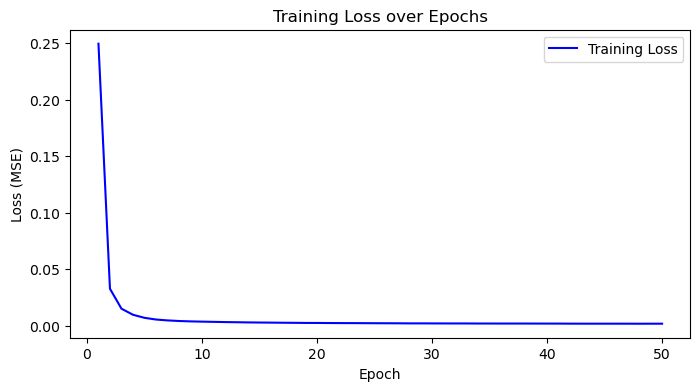

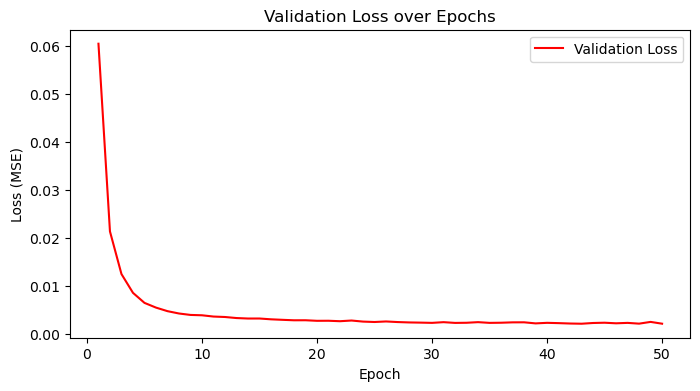

In [81]:
# Plot training loss
plt.figure(figsize=(8,4))
plt.plot(epochs, train_loss, 'b-', label='Training Loss')
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.show()

# Plot validation loss
plt.figure(figsize=(8,4))
plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
plt.title("Validation Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


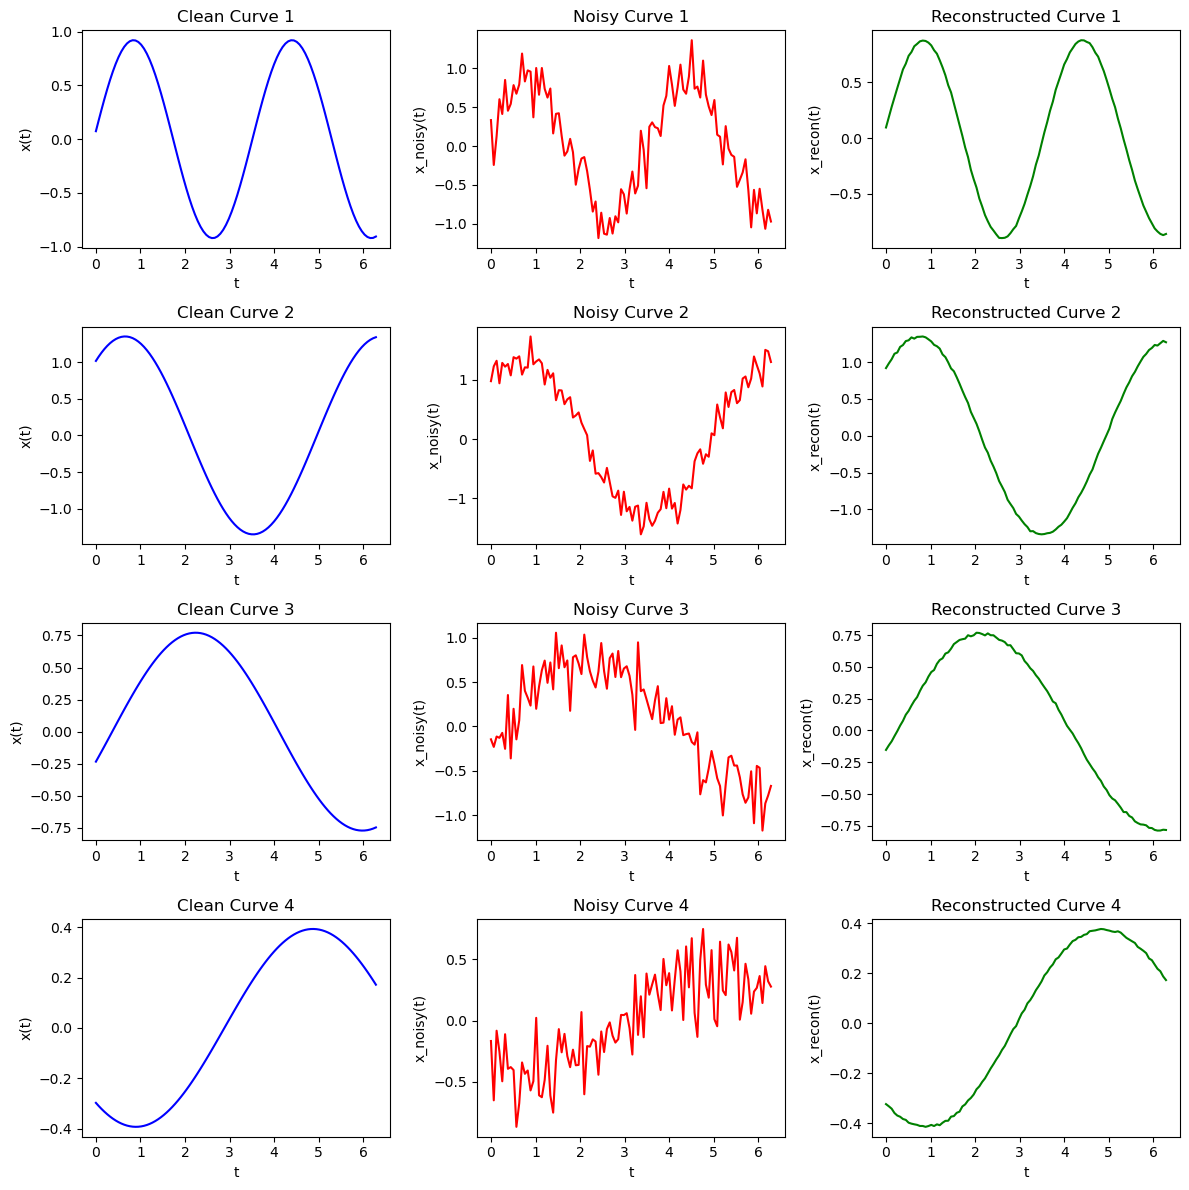

In [85]:
# Reconstruct the noisy signals
reconstructed = autoencoder.predict(noise_array[examples])

plt.figure(figsize=(12, 12))
idx = 0
for i in examples:
    # Clean signal
    plt.subplot(len(examples), 3, 3*idx + 1)
    plt.plot(t_array, base_array[i], color='blue')
    plt.title(f"Clean Curve {i+1}")
    plt.xlabel("t")
    plt.ylabel("x(t)")

    # Noisy input
    plt.subplot(len(examples), 3, 3*idx + 2)
    plt.plot(t_array, noise_array[i], color='red')
    plt.title(f"Noisy Curve {i+1}")
    plt.xlabel("t")
    plt.ylabel("x_noisy(t)")

    # Reconstructed output
    plt.subplot(len(examples), 3, 3*idx + 3)
    plt.plot(t_array, reconstructed[idx], color='green')
    plt.title(f"Reconstructed Curve {i+1}")
    plt.xlabel("t")
    plt.ylabel("x_recon(t)")

    idx +=1

plt.tight_layout()
plt.show()